<a href="https://colab.research.google.com/github/LamponeHub/System-Analysis/blob/main/WineStaticticsAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files

uploaded = files.upload()

Saving wine_reviews.csv to wine_reviews.csv


Размер датасета после очистки: (8019, 10)

Первые 5 строк:


,country,description,winery,rating,price,region,subregion,color,variety,producer
0,US,"With a delicate, silky mouthfeel and bright ac...",NaN,86,23.0,California,Central Coast,central coast,Pinot Noir,MacMurray Ranch
4,US,"Exceedingly light in color, scent and flavor, ...",NaN,83,25.0,Oregon,Rogue Valley,southern oregon,Pinot Noir,Deer Creek
6,US,"Tastes excessively sharp throughout, with a cu...",Distraction,84,40.0,California,Paso Robles,central coast,Bordeaux-style Red Blend,Pear Valley
7,US,Addictive aromas of hot blackberry pie laced w...,White Hawk Vineyard,93,40.0,California,Santa Barbara County,central coast,Syrah,Mulvane Wine Co.
8,US,Marc Piro broke away from his day job at Au Bo...,Presqu'ile Vineyard,93,44.0,California,Santa Maria Valley,central coast,Pinot Noir,Piro



Статистики по ключевым переменным:
            rating        price
count  8019.000000  8019.000000
mean     87.874922    33.643721
std       3.422876    23.281882
min      80.000000     6.000000
25%      85.000000    19.000000
50%      88.000000    28.000000
75%      90.000000    42.000000
max     100.000000   300.000000
Франция: n=0, mean=nan, std=nan
Италия: n=0, mean=nan, std=nan

Двусторонний тест: t=nan, p-value=nan
✗ Не отвергаем H₀: значимых различий в рейтингах нет


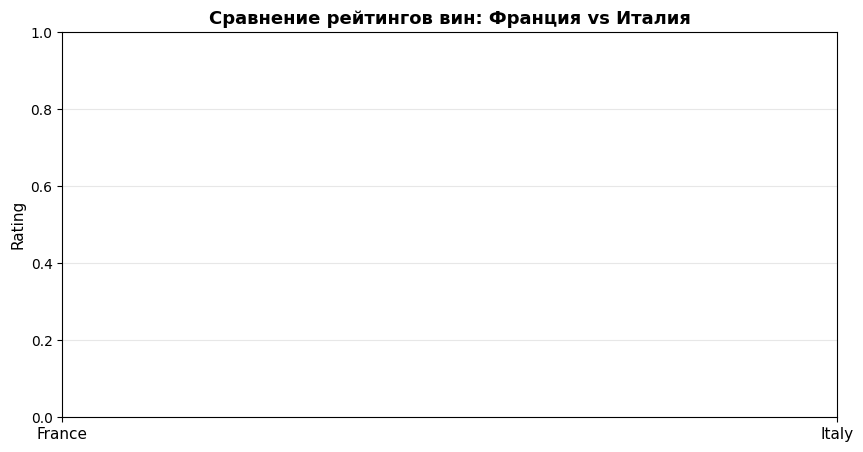

Красное: n=0, mean=$nan, std=$nan
Белое: n=0, mean=$nan, std=$nan

Двусторонний тест: t=nan, p-value=nan
✗ Не отвергаем H₀: значимых различий в ценах нет


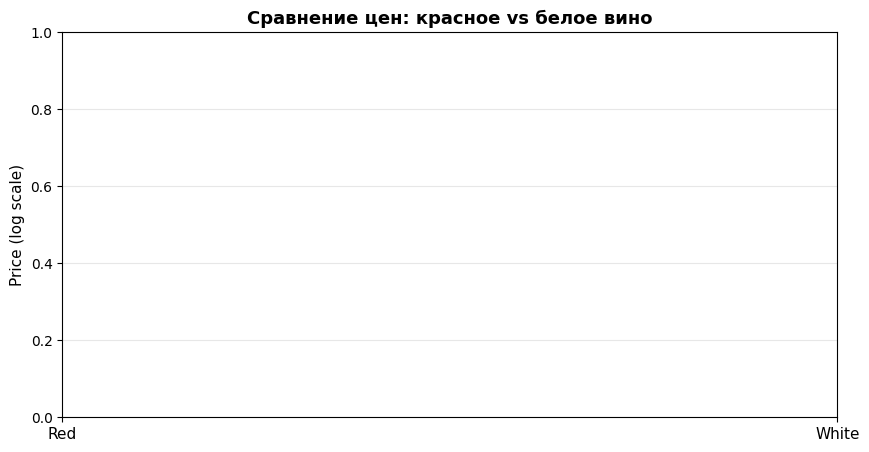

Общий размер: 8019
Обучающая выборка: 5613 наблюдений
Тестовая выборка: 2406 наблюдений


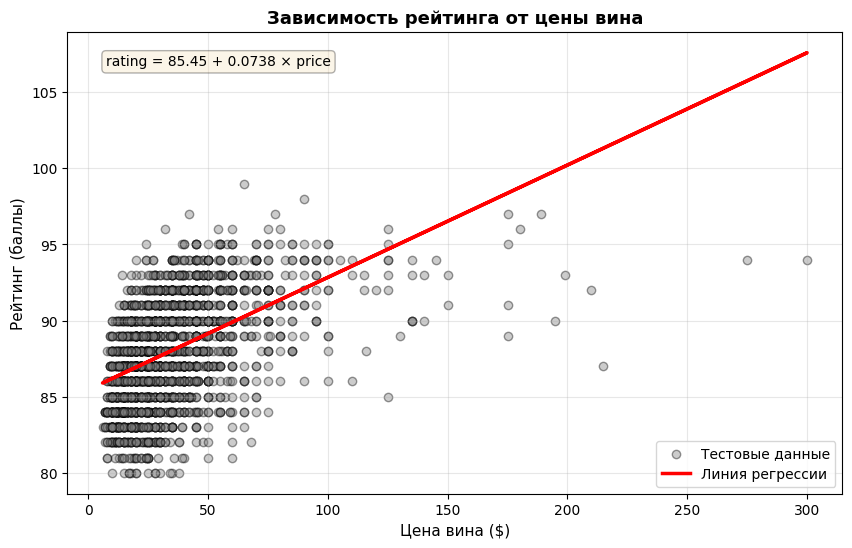

Коэффициенты модели:
  Свободный член (intercept): 85.454
  Коэффициент при price: 0.0738
  → При увеличении цены на $1 рейтинг изменяется на 0.0738 балла
Метрики качества модели (только цена):
Метрика        Значение
-------------------------
R²               0.2207
RMSE             2.9966
MAE              2.4406
MAPE             2.7895

📌 Выводы:
• Модель умеренного качества: цена имеет некоторое влияние на рейтинг
• Положительный коэффициент: более дорогие вина в среднем получают более высокие оценки
Сравнение моделей:
Метрика        Только цена     Цена + цвет    Изменение
-------------------------------------------------------
R²                  0.2207          0.2207        0.00%
RMSE                2.9966          2.9966        0.00%
MAE                 2.4406          2.4406        0.00%

📌 Выводы по добавлению цвета:
✗ Цвет вина не даёт существенного улучшения модели
• Возможно, цвет коррелирует с ценой или не является независимым предиктором рейтинга


In [9]:
# Ячейка 0: Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Ячейка 1: Загрузка и первичный осмотр данных
df = pd.read_csv('wine_reviews.csv') # Load with header (default behavior)

# Rename columns according to user's intended schema and original file structure
df = df.rename(columns={
    'designation': 'winery',
    'points': 'rating',
    'province': 'region',
    'region_1': 'subregion',
    'winery': 'producer' # Original 'winery' becomes 'producer'
})

# Define lists of common red and white wine varieties for color inference
red_varieties = [
    'pinot noir', 'cabernet sauvignon', 'merlot', 'syrah', 'shiraz',
    'zinfandel', 'sangiovese', 'grenache', 'malbec', 'tempranillo',
    'nebbiolo', 'bordeaux-style red blend', 'red blend', 'petit syrah',
    'cabernet franc', 'barbera', 'carmenere', 'mourvedre', 'gamay', 'aglianico'
]

white_varieties = [
    'chardonnay', 'sauvignon blanc', 'pinot grigio', 'pinot gris', 'riesling',
    'moscato', 'chenin blanc', 'viognier', 'gewürztraminer', 'white blend',
    'grüner veltliner', 'albarino', 'semillon', 'vermentino', 'fiano', 'garganega', 'verdelho'
]

def get_wine_color(variety):
    if isinstance(variety, str):
        variety_lower = variety.lower()
        if any(red_v in variety_lower for red_v in red_varieties):
            return 'red'
        if any(white_v in variety_lower for white_v in white_varieties):
            return 'white'
    return 'other' # For rosé, sparkling, or unknown varieties

# Create the 'color' column based on 'variety'
df['color'] = df['variety'].apply(get_wine_color)

# Очистка: удаляем строки с пропусками в ключевых переменных
df = df.dropna(subset=['rating', 'price', 'country', 'color'])

# Приводим price к числовому типу
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df.dropna(subset=['price'])

# Приводим цвет к нижнему регистру для удобства (already done by get_wine_color, but good for consistency)
df['color'] = df['color'].str.lower().str.strip()

print(f"Размер датасета после очистки: {df.shape}")
print("\nПервые 5 строк:")
display(df.head())
print("\nСтатистики по ключевым переменным:")
print(df[['rating', 'price']].describe())

# Выборка данных по странам
# Ensure 'country' column is clean for filtering
df['country'] = df['country'].str.lower().str.strip()
france_ratings = df[df['country'] == 'france']['rating']
italy_ratings = df[df['country'] == 'italy']['rating']

print(f"Франция: n={len(france_ratings)}, mean={france_ratings.mean():.2f}, std={france_ratings.std():.2f}")
print(f"Италия: n={len(italy_ratings)}, mean={italy_ratings.mean():.2f}, std={italy_ratings.std():.2f}")

# Двусторонний t-тест Уэлча (не предполагаем равенство дисперсий)
t_stat, p_value_two = stats.ttest_ind(france_ratings, italy_ratings, equal_var=False)
print(f"\nДвусторонний тест: t={t_stat:.3f}, p-value={p_value_two:.6f}")

# Решение по двустороннему тесту
alpha = 0.05
if p_value_two < alpha:
    print("✓ Отвергаем H₀: рейтинги значимо различаются")
    # Определяем направление для одностороннего теста
    if france_ratings.mean() > italy_ratings.mean():
        print("→ Французские вина имеют БОЛЕЕ ВЫСОКИЙ рейтинг")
        p_value_one = p_value_two / 2
        print(f"Односторонний тест (Франция > Италия): p-value={p_value_one:.6f}")
    else:
        print("→ Французские вина имеют БОЛЕЕ НИЗКИЙ рейтинг")
        p_value_one = p_value_two / 2
        print(f"Односторонний тест (Франция < Италия): p-value={p_value_one:.6f}")
else:
    print("✗ Не отвергаем H₀: значимых различий в рейтингах нет")

# Визуализация
plt.figure(figsize=(10, 5))
sns.boxplot(data=[france_ratings, italy_ratings], palette=['#0055A4', '#009246'], width=0.5)
plt.xticks([0, 1], ['France', 'Italy'], fontsize=11)
plt.ylabel('Rating', fontsize=11)
plt.title('Сравнение рейтингов вин: Франция vs Италия', fontsize=13, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.show()
### Гипотезы:
# H0: Цена красного и белого вина одинаковы (mu_red = mu_white)
# H1 (двусторонняя): Цены различаются (mu_red != mu_white)

# Переформулировка для одностороннего теста:
# H0: Цена красного вина <= белого (mu_red <= mu_white)
# H1: Цена красного вина > белого (mu_red > mu_white)
# Фильтрация по цвету (оставляем только red и white)
df_colors = df[df['color'].isin(['red', 'white'])].copy()
red_prices = df_colors[df_colors['color'] == 'red']['price']
white_prices = df_colors[df_colors['color'] == 'white']['price']

print(f"Красное: n={len(red_prices)}, mean=${red_prices.mean():.2f}, std=${red_prices.std():.2f}")
print(f"Белое: n={len(white_prices)}, mean=${white_prices.mean():.2f}, std=${white_prices.std():.2f}")

# Двусторонний t-тест
t_stat, p_value_two = stats.ttest_ind(red_prices, white_prices, equal_var=False)
print(f"\nДвусторонний тест: t={t_stat:.3f}, p-value={p_value_two:.6f}")

# Решение
if p_value_two < alpha:
    print("✓ Отвергаем H₀: цены значимо различаются")
    if red_prices.mean() > white_prices.mean():
        print("→ Красное вино ДОРОЖЕ белого")
    else:
        print("→ Красное вино ДЕШЕВЛЕ белого")
    p_value_one = p_value_two / 2
    print(f"Односторонний тест: p-value={p_value_one:.6f}")
else:
    print("✗ Не отвергаем H₀: значимых различий в ценах нет")

# Визуализация (логарифмическая шкала для цен)
plt.figure(figsize=(10, 5))
sns.boxplot(data=[np.log1p(red_prices), np.log1p(white_prices)],
            palette=['#8B0000', '#F0E68C'], width=0.5)
plt.xticks([0, 1], ['Red', 'White'], fontsize=11)
plt.ylabel('Price (log scale)', fontsize=11)
plt.title('Сравнение цен: красное vs белое вино', fontsize=13, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Подготовка данных для регрессии
df_reg = df[['rating', 'price', 'color']].dropna().copy()
# Кодируем цвет: red=1, white=0, rosé и другие = 0.5 (or could use dummy variables)
df_reg['color_encoded'] = df_reg['color'].map({'red': 1, 'white': 0}).fillna(0.5) # Fillna 0.5 for 'other'

# Разделение на train/test (70/30, фиксированный random_state)
X = df_reg[['price']]
y = df_reg['rating']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, shuffle=True
)

print(f"Общий размер: {len(df_reg)}")
print(f"Обучающая выборка: {len(X_train)} наблюдений")
print(f"Тестовая выборка: {len(X_test)} наблюдений")

# Обучение модели: rating ~ price
model1 = LinearRegression()
model1.fit(X_train, y_train)

# Предсказания
y_train_pred = model1.predict(X_train)
y_test_pred = model1.predict(X_test)

# Визуализация зависимости
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, alpha=0.4, label='Тестовые данные', color='gray', edgecolors='k')
plt.plot(X_test, y_test_pred, color='red', linewidth=2.5, label='Линия регрессии')
plt.xlabel('Цена вина ($)', fontsize=11)
plt.ylabel('Рейтинг (баллы)', fontsize=11)
plt.title(f'Зависимость рейтинга от цены вина', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)

# Добавляем уравнение на график
eq_text = f'rating = {model1.intercept_:.2f} + {model1.coef_[0]:.4f} × price'
plt.text(0.05, 0.95, eq_text, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
plt.show()

print(f"Коэффициенты модели:")
print(f"  Свободный член (intercept): {model1.intercept_:.3f}")
print(f"  Коэффициент при price: {model1.coef_[0]:.4f}")
print(f"  → При увеличении цены на $1 рейтинг изменяется на {model1.coef_[0]:.4f} балла")

# Метрики качества на тестовой выборке
metrics_model1 = {
    'R²': r2_score(y_test, y_test_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred)),
    'MAE': mean_absolute_error(y_test, y_test_pred),
    'MAPE': np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100
}

print("Метрики качества модели (только цена):")
print(f"{'Метрика':<10} {'Значение':>12}")
print("-" * 25)
for name, value in metrics_model1.items():
    print(f"{name:<10} {value:>12.4f}")

# Интерпретация
print(f"\n📌 Выводы:")
if metrics_model1['R²'] < 0.1:
    print("• Модель объясняет менее 10% дисперсии — цена слабо предсказывает рейтинг")
    print("• Возможно, на рейтинг влияют другие факторы: регион, сорт винограда, год урожая")
elif metrics_model1['R²'] < 0.3:
    print("• Модель умеренного качества: цена имеет некоторое влияние на рейтинг")
else:
    print("• Модель хорошего качества: цена — значимый предиктор рейтинга")

if model1.coef_[0] > 0:
    print("• Положительный коэффициент: более дорогие вина в среднем получают более высокие оценки")
else:
    print("• Отрицательный коэффициент: более дорогие вина в среднем получают более низкие оценки")

# Модель с двумя предикторами: price + color_encoded
X2 = df_reg[['price', 'color_encoded']]
y = df_reg['rating']
X2_train, X2_test, y_train, y_test = train_test_split(
    X2, y, test_size=0.3, random_state=42, shuffle=True
)

model2 = LinearRegression()
model2.fit(X2_train, y_train)
y2_test_pred = model2.predict(X2_test)

# Метрики для второй модели
metrics_model2 = {
    'R²': r2_score(y_test, y2_test_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, y2_test_pred)),
    'MAE': mean_absolute_error(y_test, y2_test_pred)
}

# Сравнение моделей
print("Сравнение моделей:")
print(f"{'Метрика':<10} {'Только цена':>15} {'Цена + цвет':>15} {'Изменение':>12}")
print("-" * 55)
for m in ['R²', 'RMSE', 'MAE']:
    val1 = metrics_model1[m]
    val2 = metrics_model2[m]
    change = ((val2 - val1) / val1 * 100) if val1 != 0 else 0
    print(f"{m:<10} {val1:>15.4f} {val2:>15.4f} {change:>11.2f}%")

# Вывод о значимости цвета
print(f"\n📌 Выводы по добавлению цвета:")
if metrics_model2['R²'] > metrics_model1['R²'] + 0.02:
    print("✓ Добавление цвета вина УЛУЧШИЛО модель (R² вырос более чем на 2 п.п.)")
    print(f"• Коэффициент для цвета: {model2.coef_[1]:.4f}")
    if model2.coef_[1] > 0:
        print("• Красное вино (код=1) в среднем получает на", f"{abs(model2.coef_[1]):.2f}", "баллов выше белого")
    else:
        print("• Красное вино (код=1) в среднем получает на", f"{abs(model2.coef_[1]):.2f}", "баллов ниже белого")
else:
    print("✗ Цвет вина не даёт существенного улучшения модели")
    print("• Возможно, цвет коррелирует с ценой или не является независимым предиктором рейтинга")